---
title: "SIR Model"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

Here, we characterise the posterior distribution associated with a susceptible-infectious-recovered (SIR) model. We will consider a similar setup to that described in @Cui2023.

# Problem Setup

We consider the SIR model given by the system of ODEs

$$
\frac{\mathrm{d}S(t)}{\mathrm{d}t} = -\beta S I, \quad 
\frac{\mathrm{d}I(t)}{\mathrm{d}t} = \beta S I - \gamma I, \quad 
\frac{\mathrm{d}R(t)}{\mathrm{d}t} = \gamma I,
$$

where $S(t)$, $I(t)$ and $R(t)$ denote the number of susceptible, infectious and recovered people at time $t$, and $\beta$ and $\gamma$ are unknown parameters. For the sake of simplicity, we assume that $S(t)$, $I(t)$ and $R(t)$ can take non-integer values.

We will assume that the initial conditions for the problem are given by $S(0) = 99$, $I(0) = 1$, $R(0) = 0$, and that we receive four noisy observations of the number of infectious people, at times $t \in \{1.25, 2.5, 3.75, 5\}$. We will assume that each of these observations is corrupted by additive, independent Gaussian noise with a mean of $0$ and a standard deviation of $1$. 

Finally, we will choose a uniform prior for $\beta$ and $\gamma$; that is, $(\beta, \gamma) \sim \mathcal{U}([0, 2]^{2})$.

# Implementation in $\mathtt{deep\_tensor}$

To solve this inference problem using $\mathtt{deep\_tensor}$, we begin by importing the relevant libraries and defining the SIR model.

In [6]:
from matplotlib import pyplot as plt
import torch
from torch import Tensor

import deep_tensor as dt
from examples.sir import SIRModel
from examples.plotting import add_arrows, set_plot_style

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1)
set_plot_style()

In [8]:
model = SIRModel()

Next, we generate some synthetic observations. We will assume that the true values of the parameters are $(\beta, \gamma) = (0.1, 1.0)$.

In [9]:
xs_true = torch.tensor([[0.1, 1.0]], device=device)
ys_true = model.solve(xs_true)
noise = torch.randn_like(ys_true)
ys_obs = ys_true + noise

## DIRT Construction

We now illustrate how to construct a DIRT approximation to the posterior.

### Posterior Density

We first define a function that returns the potential function (*i.e.*, the negative logarithm) of the posterior at a set of samples.

::: {.callout-note}
The function below accepts a matrix of samples of the parameter, where each row contains a single sample. It returns a vector containing the potential function evaluated at each sample.
:::

In this example, we will restrict the DIRT approximation to the posterior to the support of the prior, which is uniform. Therefore, the function we define only needs to return the negative log-likelihood of each sample.

In [10]:
def neglogpost(xs: Tensor) -> Tensor:
    ys = model.solve(xs)
    neglogliks = 0.5 * (ys - ys_obs).square().sum(dim=1)
    return neglogliks

target_func = dt.TargetFunc(neglogpost)

### Reference Density and Preconditioner

Next, we specify a product-form reference density. A suitable choice in most cases is the standard Gaussian density.

We must also specify a *preconditioner*. Recall that the DIRT object provides a coupling between a product-form reference density and an approximation to the target density. A preconditioner can be considered an initial guess as to what this coupling is.

Choosing an suitable preconditioner can reduce the computational expense required to construct the DIRT object significantly. In the context of a Bayesian inverse problem, a suitable choice is a coupling between the reference density and the prior.

In [11]:
bounds = torch.tensor([[0.0, 2.0], [0.0, 2.0]])
reference = dt.GaussianReference()
preconditioner = dt.UniformMapping(bounds, reference)

### Functional Tensor Train

Next, we construct a functional tensor train (FTT) object, which will be used to approximate each of the layers of the DIRT.

The FTT requires a set of the basis functions. We can specify a list of bases in each dimension, or a single basis (which will be used in all dimensions). Here, we use a basis comprised of Legendre polynomials with a maximum degree of 30 in each dimension.

In [12]:
basis = dt.Legendre(order=30, device=device)
bases = dt.ApproxBases(basis, dim=2)

tt = dt.TT(device=device)
ftt = dt.FTT(bases, tt, device=device)

### DIRT Approximation

Now we can construct the DIRT approximation to the posterior.

In [13]:
dirt = dt.DIRT(target_func, preconditioner, ftt, device=device)

[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 2.28e-01 s | Beta: 0.0001 | DHell: 0.0000 | ESS: 0.9762
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       2364 |       22 |       1.00e+00 |        1.00e+00 | 2.05e-03
[ALS]  ALS complete.
[DIRT] Iter:  2 | Cum. Fevals: 3.36e+03 | Cum. Time: 1.84e+00 s | Beta: 0.0039 | DHell: 0.0013 | ESS: 0.4918
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       2364 |       22 |       6.56e-01 |        3.31e-01 | 5.46e-02
[ALS]  ALS complete.
[DIRT] Iter:  3 | Cum. Fevals: 6.73e+03 | Cum. Time: 2.75e+00 s | Beta: 0.0236 | DHell: 0.0345 | ESS: 0.4884
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       2364 |       22 |       2.73e-01 |        1.36e-01 | 2.21e-02
[ALS]  ALS complete.
[DIRT] Iter:  4 | Cum. Fevals: 1.01e+04 | Cum. Time: 3.96e+00 s | Beta: 0.0725 | DHell: 0.0230 | ESS: 0.4881
[ALS]  It

Observe that a set of diagnostic information is printed at each stage of DIRT construction.

Note that we did not specify a set of bridging densities to guide the DIRT construction; instead, these were determined adaptively.

## Sampling, Marginalisation and Conditioning

We now illustrate how to use the DIRT approximation to carry out a range of tasks.

### Sampling

First, it is possible to evaluate the DIRT approximation to the target density pointwise. The below code evaluates the potential function associated with the DIRT approximation to the target density, on a grid of $\beta$ and $\gamma$ values.

In [14]:
# Define grid to evaluate potential function on
n_grid = 200
beta_grid = torch.linspace(0.05, 0.14, n_grid, device=device)
gamma_grid = torch.linspace(0.80, 1.40, n_grid, device=device)
grid = torch.tensor([[b, g] for g in gamma_grid for b in beta_grid], device=device)

# Evaluate potential function
potentials_grid = dirt.eval_potential(grid)

@fig-post shows a plot of the DIRT density evaluated on the above grid and compares it to the true posterior. The posterior is very concentrated in comparison to the prior (particularly for parameter $\beta$).

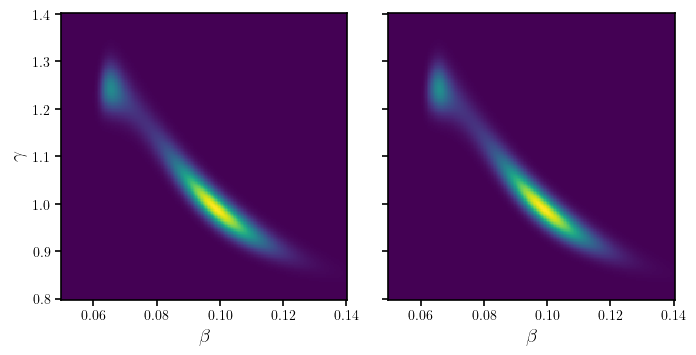

In [15]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A comparison between the true posterior density (left) and the DIRT approximation (right).
#| label: fig-post

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True, sharey=True)

# Compute true density
pdf_true = torch.exp(-neglogpost(grid))
pdf_true = pdf_true.reshape(n_grid, n_grid)

# Normalise true density
db = beta_grid[1] - beta_grid[0]
dg = gamma_grid[1] - gamma_grid[0]
pdf_true /= (pdf_true.sum() * db * dg)

# Compute DIRT approximation
pdf_dirt = torch.exp(-potentials_grid)
pdf_dirt = pdf_dirt.reshape(n_grid, n_grid)

axes[0].pcolormesh(beta_grid, gamma_grid, pdf_true)
axes[1].pcolormesh(beta_grid, gamma_grid, pdf_dirt)
axes[0].set_ylabel(r"$\gamma$")
for ax in axes:
    ax.set_xlabel(r"$\beta$")
    ax.set_box_aspect(1)

plt.show()

We can sample from the DIRT density by drawing a set of samples from the reference density and calling the `eval_irt` method of the DIRT object. Note that the `eval_irt` method also returns the potential function of the DIRT density evaluated at each sample.

In [16]:
rs = dirt.reference.random(n=20, d=dirt.dim)
samples, potentials = dirt.eval_irt(rs)

@fig-samples shows a plot of the samples.

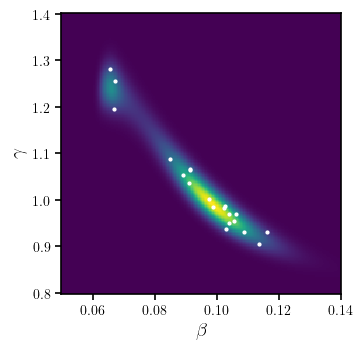

In [17]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Samples from the DIRT approximation to the posterior.
#| label: fig-samples

fig, ax = plt.subplots(figsize=(7, 3.5), sharex=True, sharey=True)

ax.pcolormesh(beta_grid, gamma_grid, pdf_dirt)
ax.scatter(*samples.T, c="white", s=4)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\gamma$")
ax.set_box_aspect(1)

plt.show()

### Marginalisation

We can also sample from and evaluate specific marginal densities. In the case of a multi-layered DIRT, we can evaluate the (normalised) DIRT approximation to the marginal density of the first $k$ variables, where $1 \leq k \leq d$ (where $d$ denotes the dimension of the target random variable).

The below code generates a set of samples from the marginal density of parameter $\beta$, and evaluates the marginal density on a grid of $\beta$ values.

In [18]:
# Generate marginal samples of parameter beta
rs_beta = dirt.reference.random(n=1000, d=1, device=device)
samples_beta, potentials_beta = dirt.eval_irt(rs_beta, subset="first")

# Evaluate marginal potential on the grid of beta values defined previously
potentials_grid = dirt.eval_potential(beta_grid[:, None], subset="first")

@fig-marginal plots the samples of $\beta$, and provides a comparison between the DIRT approximation to the density and the true density.

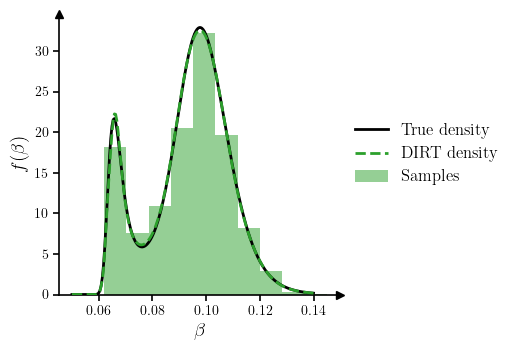

In [19]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A comparison between the true marginal density of $\beta$ and the DIRT approximation.
#| label: fig-marginal

pdf_true_marg = pdf_true.sum(dim=0) * dg
pdf_dirt_marg = torch.exp(-potentials_grid)

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.plot(beta_grid, pdf_true_marg, c="k", label=r"True density", zorder=2)
ax.plot(beta_grid, pdf_dirt_marg, c="tab:green", ls="--", label=r"DIRT density", zorder=3)
ax.hist(samples_beta, color="tab:green", density=True, alpha=0.5, zorder=1, label="Samples")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$f(\beta)$")
ax.set_box_aspect(1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
add_arrows(ax)

plt.show()

### Conditioning

Finally, we can sample from and evaluate specific conditional densities. In the case of a multi-layered DIRT, we can evaluate the (normalised) DIRT approximation to the conditional density of the final $(d-k)$ variables conditioned on the first $k$ variables, where $1 \leq k < d$ (where $d$ denotes the dimension of the target random variable).

The below code generates a set of samples from the density of $\gamma$ conditioned on a value of $\beta=0.1$, and evaluates the conditional density on a grid of $\gamma$ values.

In [20]:
# Define beta value to condition on
beta_cond = torch.tensor([[0.10]], device=device)

# Generate conditional samples of gamma
rs_cond = dirt.reference.random(n=1000, d=1, device=device)
samples_gamma, potentials_gamma = dirt.eval_cirt(beta_cond, rs_cond, subset="first")

# Evaluate conditional potential on a grid of gamma values
gamma_grid = torch.linspace(0.9, 1.1, 200, device=device)[:, None]
potentials_grid = dirt.eval_potential_cond(beta_cond, gamma_grid, subset="first")

@fig-conditional plots the conditional samples of $\gamma$, and provides a comparison between the DIRT approximation to the conditional density and the true density.

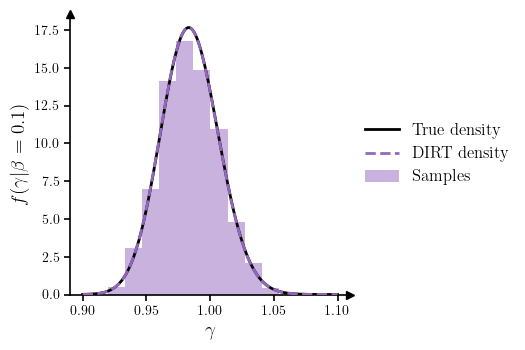

In [21]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A comparison between the true conditional density of $\gamma | \beta = 0.1$ and the DIRT approximation.
#| label: fig-conditional

beta_cond = beta_cond.repeat(gamma_grid.shape[0], 1)
grid_cond = torch.hstack((beta_cond, gamma_grid))
dg = gamma_grid[1] - gamma_grid[0]

# Evaluate true conditional density
pdf_true_cond = torch.exp(-neglogpost(grid_cond)).flatten()
pdf_dirt_cond = torch.exp(-potentials_grid)

# Normalise true conditional density
pdf_true_cond /= (pdf_true_cond.sum() * dg)

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.plot(gamma_grid, pdf_true_cond, c="k", label=r"True density", zorder=3)
ax.plot(gamma_grid, pdf_dirt_cond, c="tab:purple", ls="--", label=r"DIRT density", zorder=3)
ax.hist(samples_gamma, color="tab:purple", density=True, alpha=0.5, zorder=1, label="Samples")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$f(\gamma|\beta=0.1)$")
ax.set_box_aspect(1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
add_arrows(ax)

plt.show()